In [2]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from pathlib import Path
from datetime import datetime
import pytz
import geopandas as gpd

In [3]:
df_grid = pd.read_csv(Path("data/victoria_grid_1km.csv"))

In [4]:
km = 50
lat_step = km / 111
lon_step = km / (111 * np.cos(np.radians(37)))

lats = np.arange(-40.0, -33.5, lat_step)
lons = np.arange(140.0, 151.0, lon_step)
grid_lats, grid_lons = np.meshgrid(lats, lons)

df_sample = pd.DataFrame({
    "lat": grid_lats.ravel(),
    "lon": grid_lons.ravel(),
})
print(f"Cells: {len(df_sample)}")

Cells: 300


In [5]:
poa = gpd.read_file("POA_2021_AUST_GDA2020.shp").set_crs(epsg=4326)
poa_vic = poa[poa["POA_CODE21"].str.startswith("3")]

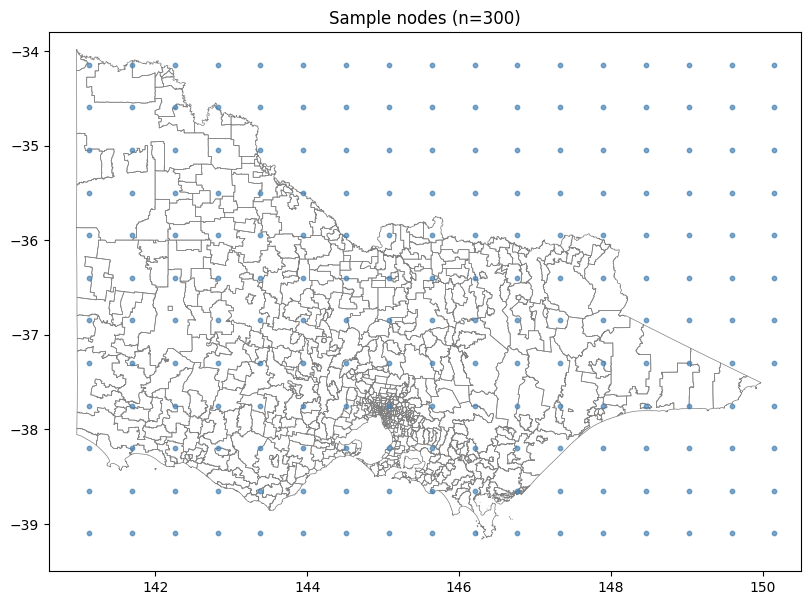

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
poa_vic.plot(ax=ax, edgecolor="gray", facecolor="none", linewidth=0.5)
ax.scatter(df_sample["lon"], df_sample["lat"], s=10, color="steelblue", alpha=0.7)
ax.set_xlim(140.6, 150.5)
ax.set_ylim(-39.5, -33.8)
ax.set_title(f"Sample nodes (n={len(df_sample)})")
plt.show()

In [7]:
response = requests.post(
    "https://api.open-meteo.com/v1/forecast",
    json={
        "latitude": df_sample["lat"].tolist(),
        "longitude": df_sample["lon"].tolist(),
        "hourly": ["temperature_2m", "relative_humidity_2m", "wind_speed_10m"],
        "forecast_days": 1,
    },
    timeout=60,
)
response.raise_for_status()
payload = response.json()
if isinstance(payload, dict):
    payload = [payload]

now_utc = datetime.now(pytz.utc).replace(minute=0, second=0, microsecond=0)
tz = pytz.timezone("Australia/Melbourne")
now_local = now_utc.astimezone(tz)

rows = []
for loc in payload:
    hourly = loc["hourly"]
    times = pd.to_datetime(hourly["time"]).tz_localize("UTC")
    idx_now = np.abs((times - now_utc).total_seconds()).argmin()

    rows.append({
        "time": now_local.strftime("%Y-%m-%dT%H:%M"),
        "lat": loc["latitude"],
        "lon": loc["longitude"],
        "temperature_2m": hourly["temperature_2m"][idx_now],
        "relative_humidity_2m": hourly["relative_humidity_2m"][idx_now],
        "wind_speed_10m": hourly["wind_speed_10m"][idx_now],
    })

df_weather = pd.DataFrame(rows)
_, idx = cKDTree(df_grid[["lat", "lon"]].values).query(df_weather[["lat", "lon"]].values)
df_weather["postcode"] = df_grid.iloc[idx]["postcode"].values
df_weather

,time,lat,lon,temperature_2m,relative_humidity_2m,wind_speed_10m,postcode
0,2026-04-21T17:00,-40.000,140.00,15.1,87,24.5,NaN
1,2026-04-21T17:00,-39.500,140.00,15.1,90,21.6,NaN
2,2026-04-21T17:00,-39.125,140.00,15.6,90,19.8,NaN
3,2026-04-21T17:00,-38.625,140.00,16.5,89,14.9,NaN
4,2026-04-21T17:00,-38.250,140.00,17.5,89,14.4,NaN
...,...,...,...,...,...,...,...
295,2026-04-21T17:00,-35.500,150.75,19.5,64,27.8,NaN
296,2026-04-21T17:00,-35.000,150.75,17.8,73,14.4,NaN
297,2026-04-21T17:00,-34.625,150.75,13.7,80,14.6,NaN
298,2026-04-21T17:00,-34.125,150.75,17.3,64,12.4,NaN


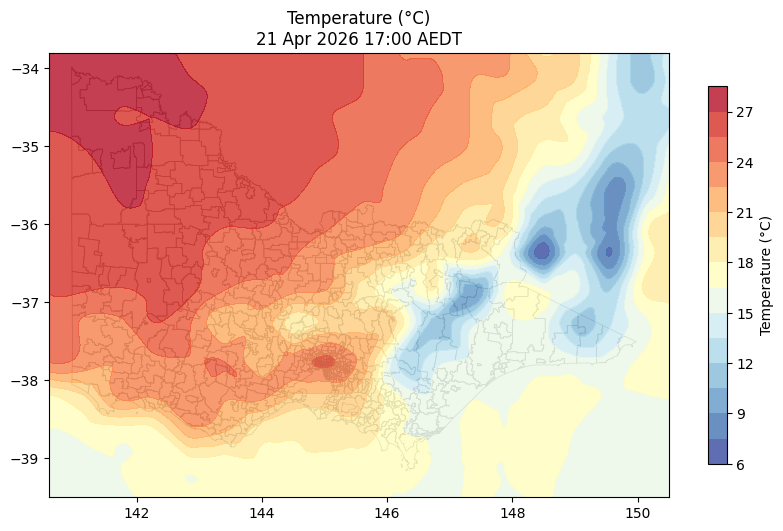

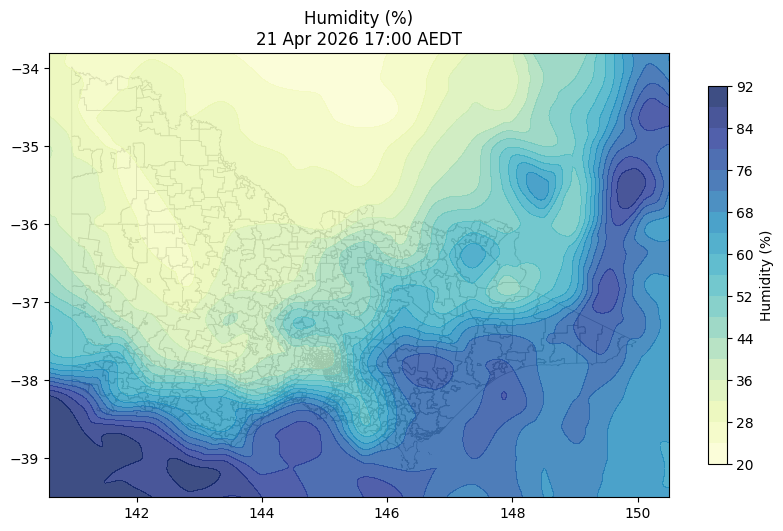

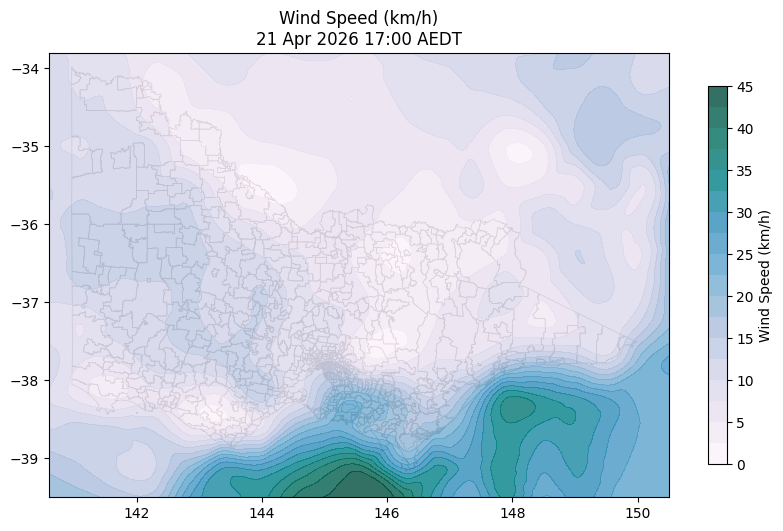

In [8]:
grid_lon, grid_lat = np.meshgrid(
    np.linspace(140.6, 150.5, 200),
    np.linspace(-39.5, -33.8, 200),
)
points = df_weather[["lon", "lat"]].values

VARS = [
    ("temperature_2m", "Temperature (°C)", "RdYlBu_r"),
    ("relative_humidity_2m", "Humidity (%)", "YlGnBu"),
    ("wind_speed_10m", "Wind Speed (km/h)", "PuBuGn"),
]

time_label = pd.to_datetime(df_weather["time"].iloc[0]).strftime("%d %b %Y %H:%M")

for var, label, cmap in VARS:
    z = griddata(points, df_weather[var].values, (grid_lon, grid_lat), method="cubic")

    fig, ax = plt.subplots(figsize=(10, 7))
    poa_vic.plot(ax=ax, edgecolor="gray", facecolor="none", linewidth=0.5)
    cf = ax.contourf(grid_lon, grid_lat, z, levels=20, cmap=cmap, alpha=0.8)
    plt.colorbar(cf, ax=ax, label=label, shrink=0.7)
    ax.set_title(f"{label}\n{time_label} AEDT")
    plt.show()

## Interpolate to `df_grid`

In [9]:
points = df_weather[["lon", "lat"]].values

for var, _, _ in VARS:
    df_grid[var] = griddata(
        points,
        df_weather[var].values,
        df_grid[["lon", "lat"]].values,
        method="cubic"
    )

df_grid

,lat,lon,postcode,temperature_2m,relative_humidity_2m,wind_speed_10m
0,-37.925576,147.967156,NaN,16.211131,77.073530,22.905680
1,-37.934588,147.967275,NaN,16.218365,77.186318,23.364314
2,-37.943600,147.967393,NaN,16.225514,77.299411,23.823265
3,-37.952611,147.967511,NaN,16.232579,77.412541,24.282007
4,-37.961623,147.967629,NaN,16.239564,77.525437,24.740013
...,...,...,...,...,...,...
463801,-38.168499,144.705528,3223.0,20.949275,64.410822,11.146372
463802,-38.381932,150.501182,NaN,16.349918,64.854675,23.399075
463803,-38.189359,145.424190,3981.0,20.702704,56.085898,21.217967
463804,-38.147712,150.501112,NaN,16.686468,64.983522,23.628924


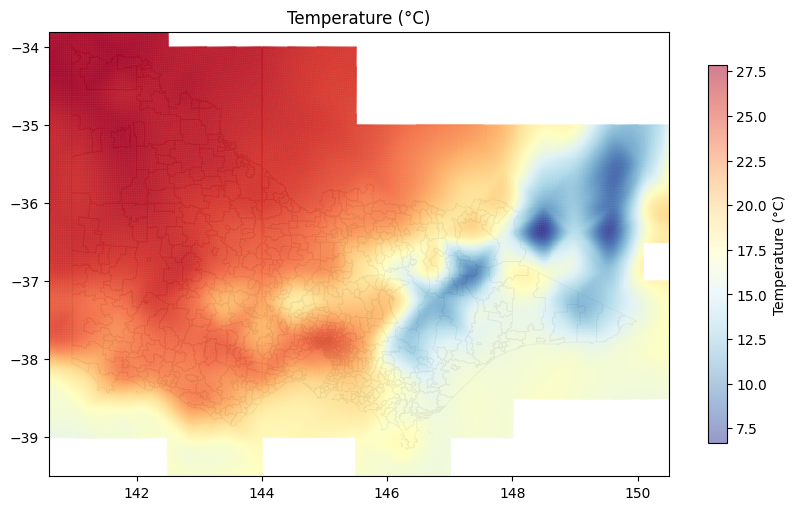

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
poa_vic.plot(ax=ax, edgecolor="gray", facecolor="none", linewidth=0.5)
sc = ax.scatter(df_grid["lon"], df_grid["lat"], c=df_grid["temperature_2m"], cmap="RdYlBu_r", s=0.1, alpha=0.5)
plt.colorbar(sc, ax=ax, label="Temperature (°C)", shrink=0.7)
ax.set_xlim(140.6, 150.5)
ax.set_ylim(-39.5, -33.8)
ax.set_title("Temperature (°C)")
plt.show()

In [11]:
_grid_tree = cKDTree(df_grid[["lat", "lon"]].values)

def snap_to_grid(lat, lon):
    _, idx = _grid_tree.query([lat, lon])
    return df_grid.iloc[idx]

def get_weather_for_postcode(postcode):
    rows = df_grid[df_grid["postcode"] == postcode]
    return rows[["temperature_2m", "relative_humidity_2m", "wind_speed_10m"]].mean()

def get_weather_for_region(lat_min, lat_max, lon_min, lon_max):
    mask = (
        (df_grid["lat"] >= lat_min) & (df_grid["lat"] <= lat_max) &
        (df_grid["lon"] >= lon_min) & (df_grid["lon"] <= lon_max)
    )
    return df_grid[mask]

In [12]:
result = snap_to_grid(-37.8136, 144.9631)
result

lat                      -37.812849
lon                      144.966484
postcode                3000.000000
temperature_2m            24.132206
relative_humidity_2m      42.013005
wind_speed_10m            10.856679
Name: 273994, dtype: float64